# Nipigon sills and lavas ca. 1108 Ma paleomagnetic pole

## Geologic context

The Nipigon sills (previously termed the Logan sills) are reversely magnetized mafic sills and associated lavas of the Nipigon Embayment on the north shore of Lake Superior, emplaced during the earliest magmatic stage of the Midcontinent Rift. This entry is the Lulea Working Group grand mean of eight Nipigon-region units, combining sill and lava results that together record a single reverse-polarity direction.

## Paleomagnetic data

The pole is the eight-unit mean compiled by the Lulea Working Group (2009) and carried in the Evans et al. (2021) Laurentia compilation. As listed there, the contributing units are the Inspiration sills, the Pillar Lake lava, the Seagull intrusion (Borradaile et al., 2006), the Nipigon sills (Middleton et al., 2004), three Logan sills results (Pesonen, 1979; Robertson and Fahrig, 1971; Palmer, 1970), and the Thunder Bay reverse dykes (Pesonen, 1979). The mean direction at the reference locality is Dec/Inc = 107.6 degrees / -70.9 degrees, giving a pole at 47.2 degrees N / 217.8 degrees E with A95 = 4.0 degrees from B = 86 sites. The remanence is single (reverse) polarity, and the pole carries a positive inverse baked-contact constraint (field-test code c).

## Age

The Nipigon (Logan) sills cluster in age near 1105-1109 Ma. The Nipigon sills are dated at 1108.2 +/- 0.9 Ma (zircon upper intercept, recalculated from the data of Davis and Sutcliffe, 1985), and Bleeker et al. (2020) report new high-precision U-Pb dates of 1106.3 +/- 2.0 Ma for the main Logan Sill at Mount McKay and 1105.5 +/- 3.0 Ma for the Inspiration sill. The pole is assigned an age of 1108 +/- 2 Ma. The older Heaman et al. (2007) baddeleyite dates are imprecise and superseded and are not used here.

## References

Paleomagnetic pole: Lulea Working Group mean (2009), as compiled in Evans et al. (2021). Geochronology: Davis and Sutcliffe (1985); Bleeker et al. (2020).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the Evans et al. (2021) Laurentia compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed because the underlying per-unit data are not digitized in this repository; this is a published grand mean carried forward into the Nordic compilation format.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
nip = evans[evans['ROCKNAME'] == 'MEAN Nipigon sills and lavas'].iloc[0]

pole_mean = {'dec': float(nip['PLONG']), 'inc': float(nip['PLAT']),
             'alpha95': float(nip['A95']), 'n': int(float(nip['B']))}
dir_mean = {'dec': float(nip['DEC']), 'inc': float(nip['INC']),
            'alpha95': float(nip['ED95']), 'k': float(nip['KD'])}

print('Nipigon sills and lavas pole (Evans et al., 2021 compilation):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  B {pole_mean['n']} sites")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (%REV {int(float(nip['%REV']))})")

Nipigon sills and lavas pole (Evans et al., 2021 compilation):
  PLAT 47.2  PLON 217.8  A95 4.0  B 86 sites
  mean direction Dec 107.6  Inc -70.9  (%REV 100)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
Laurentia_poles = pt.get_Laurentia_poles()
pt.R2_test('MEAN Nipigon sills and lavas', Laurentia_poles)

N = 1000 (N ≥ 25; sufficient sample number);
B = 86 (B ≥ 8; sufficient site number);
K = 1000 (K ≥ 70; concern about underrepresenting PSV);
A_95 of 4.0 passes Deenen et al. (2011) criteria of being between 2.0 and 5.0 for this number of sites


## Position within the Laurentia apparent polar wander path

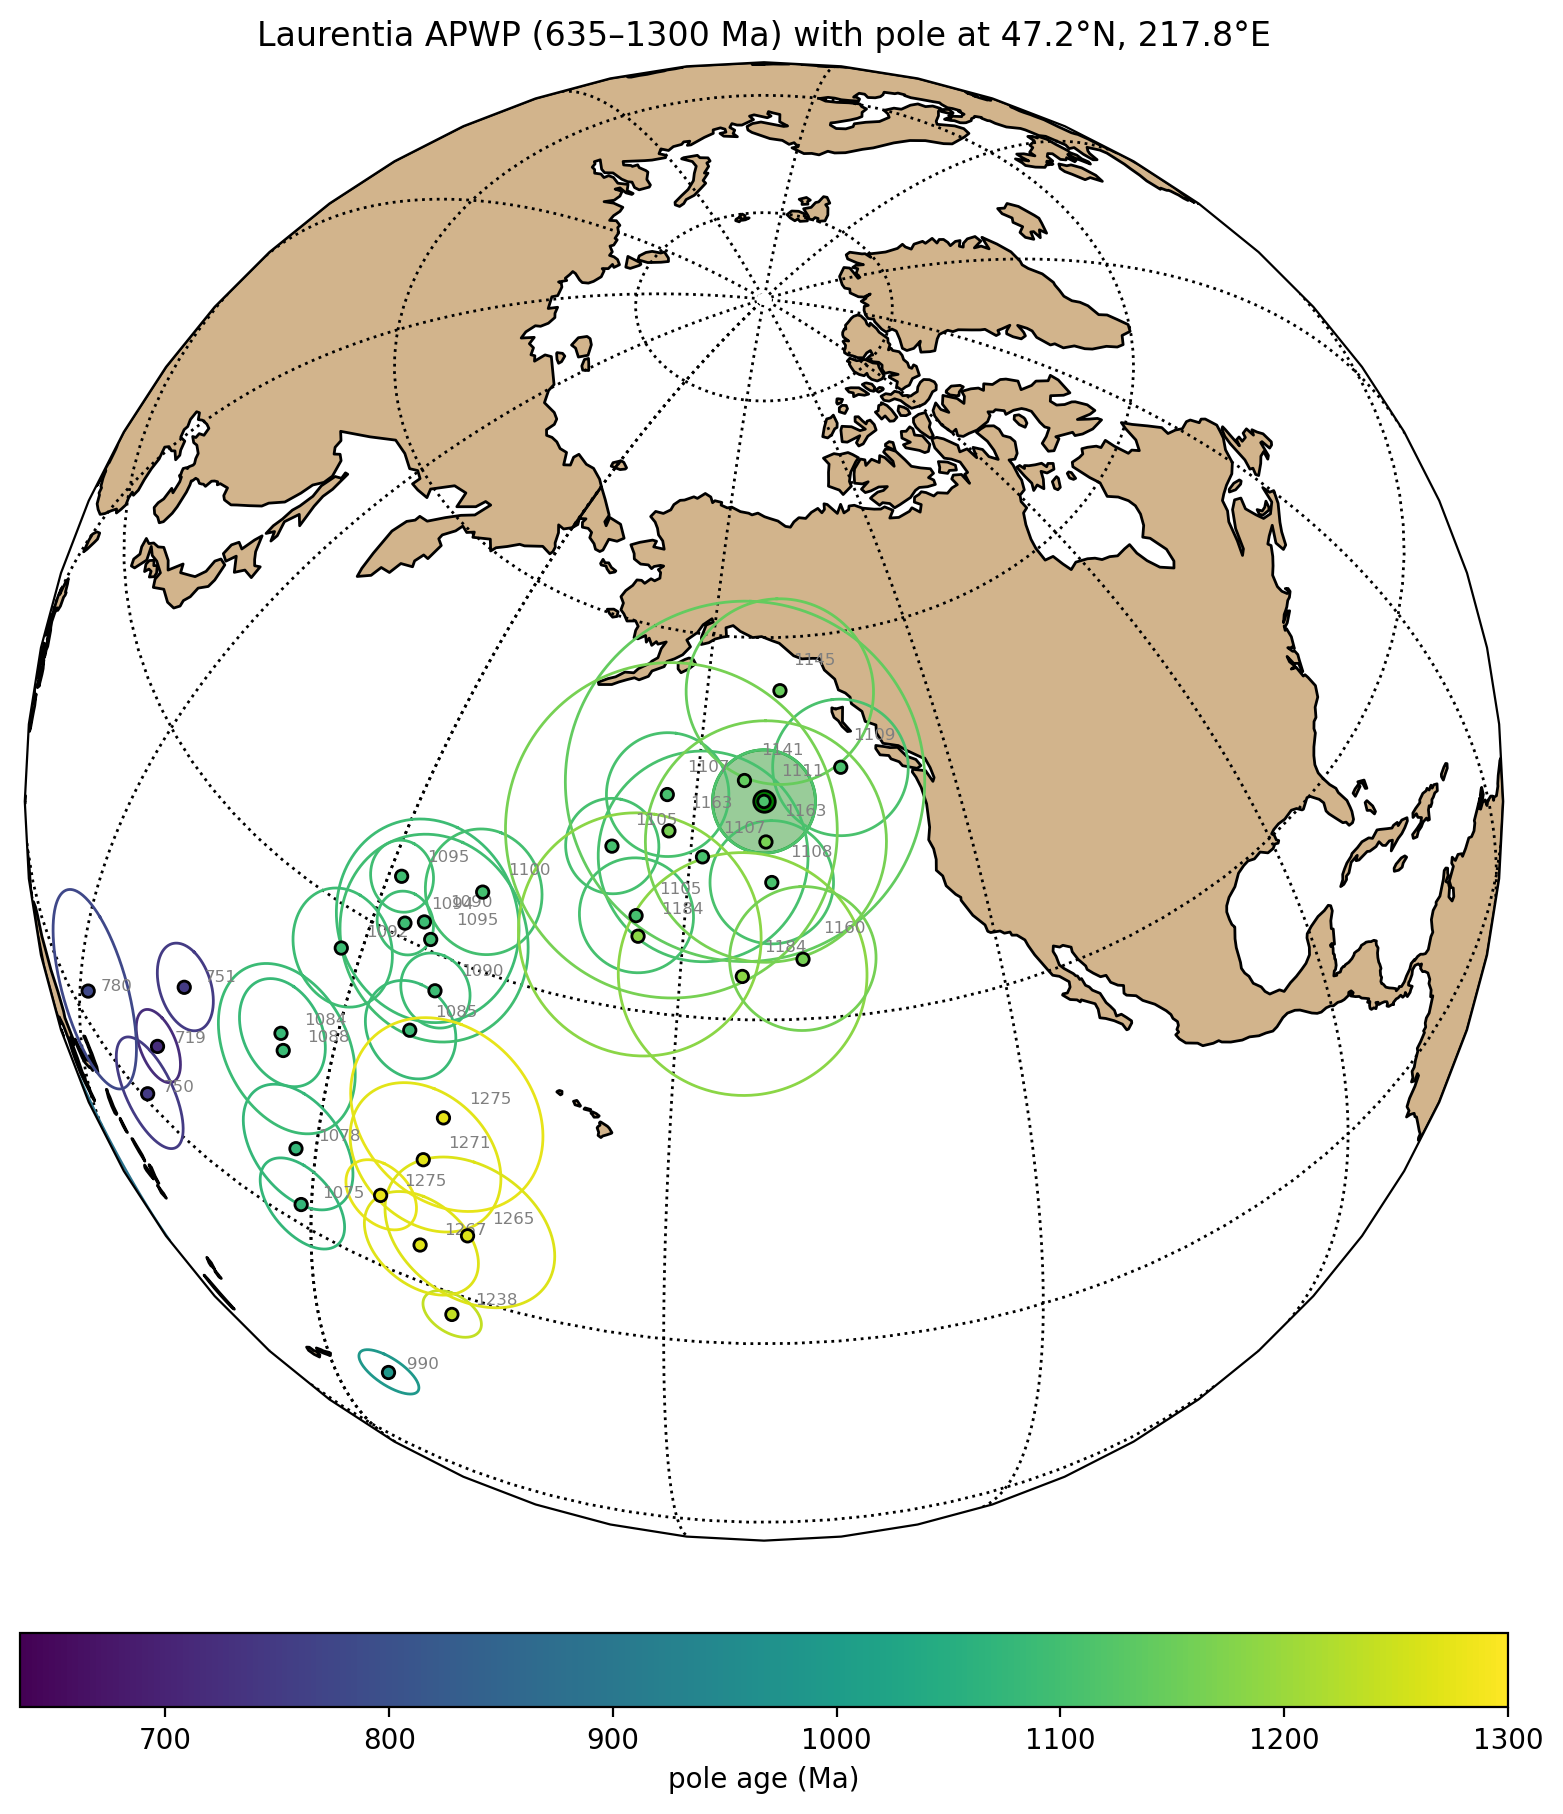

In [4]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

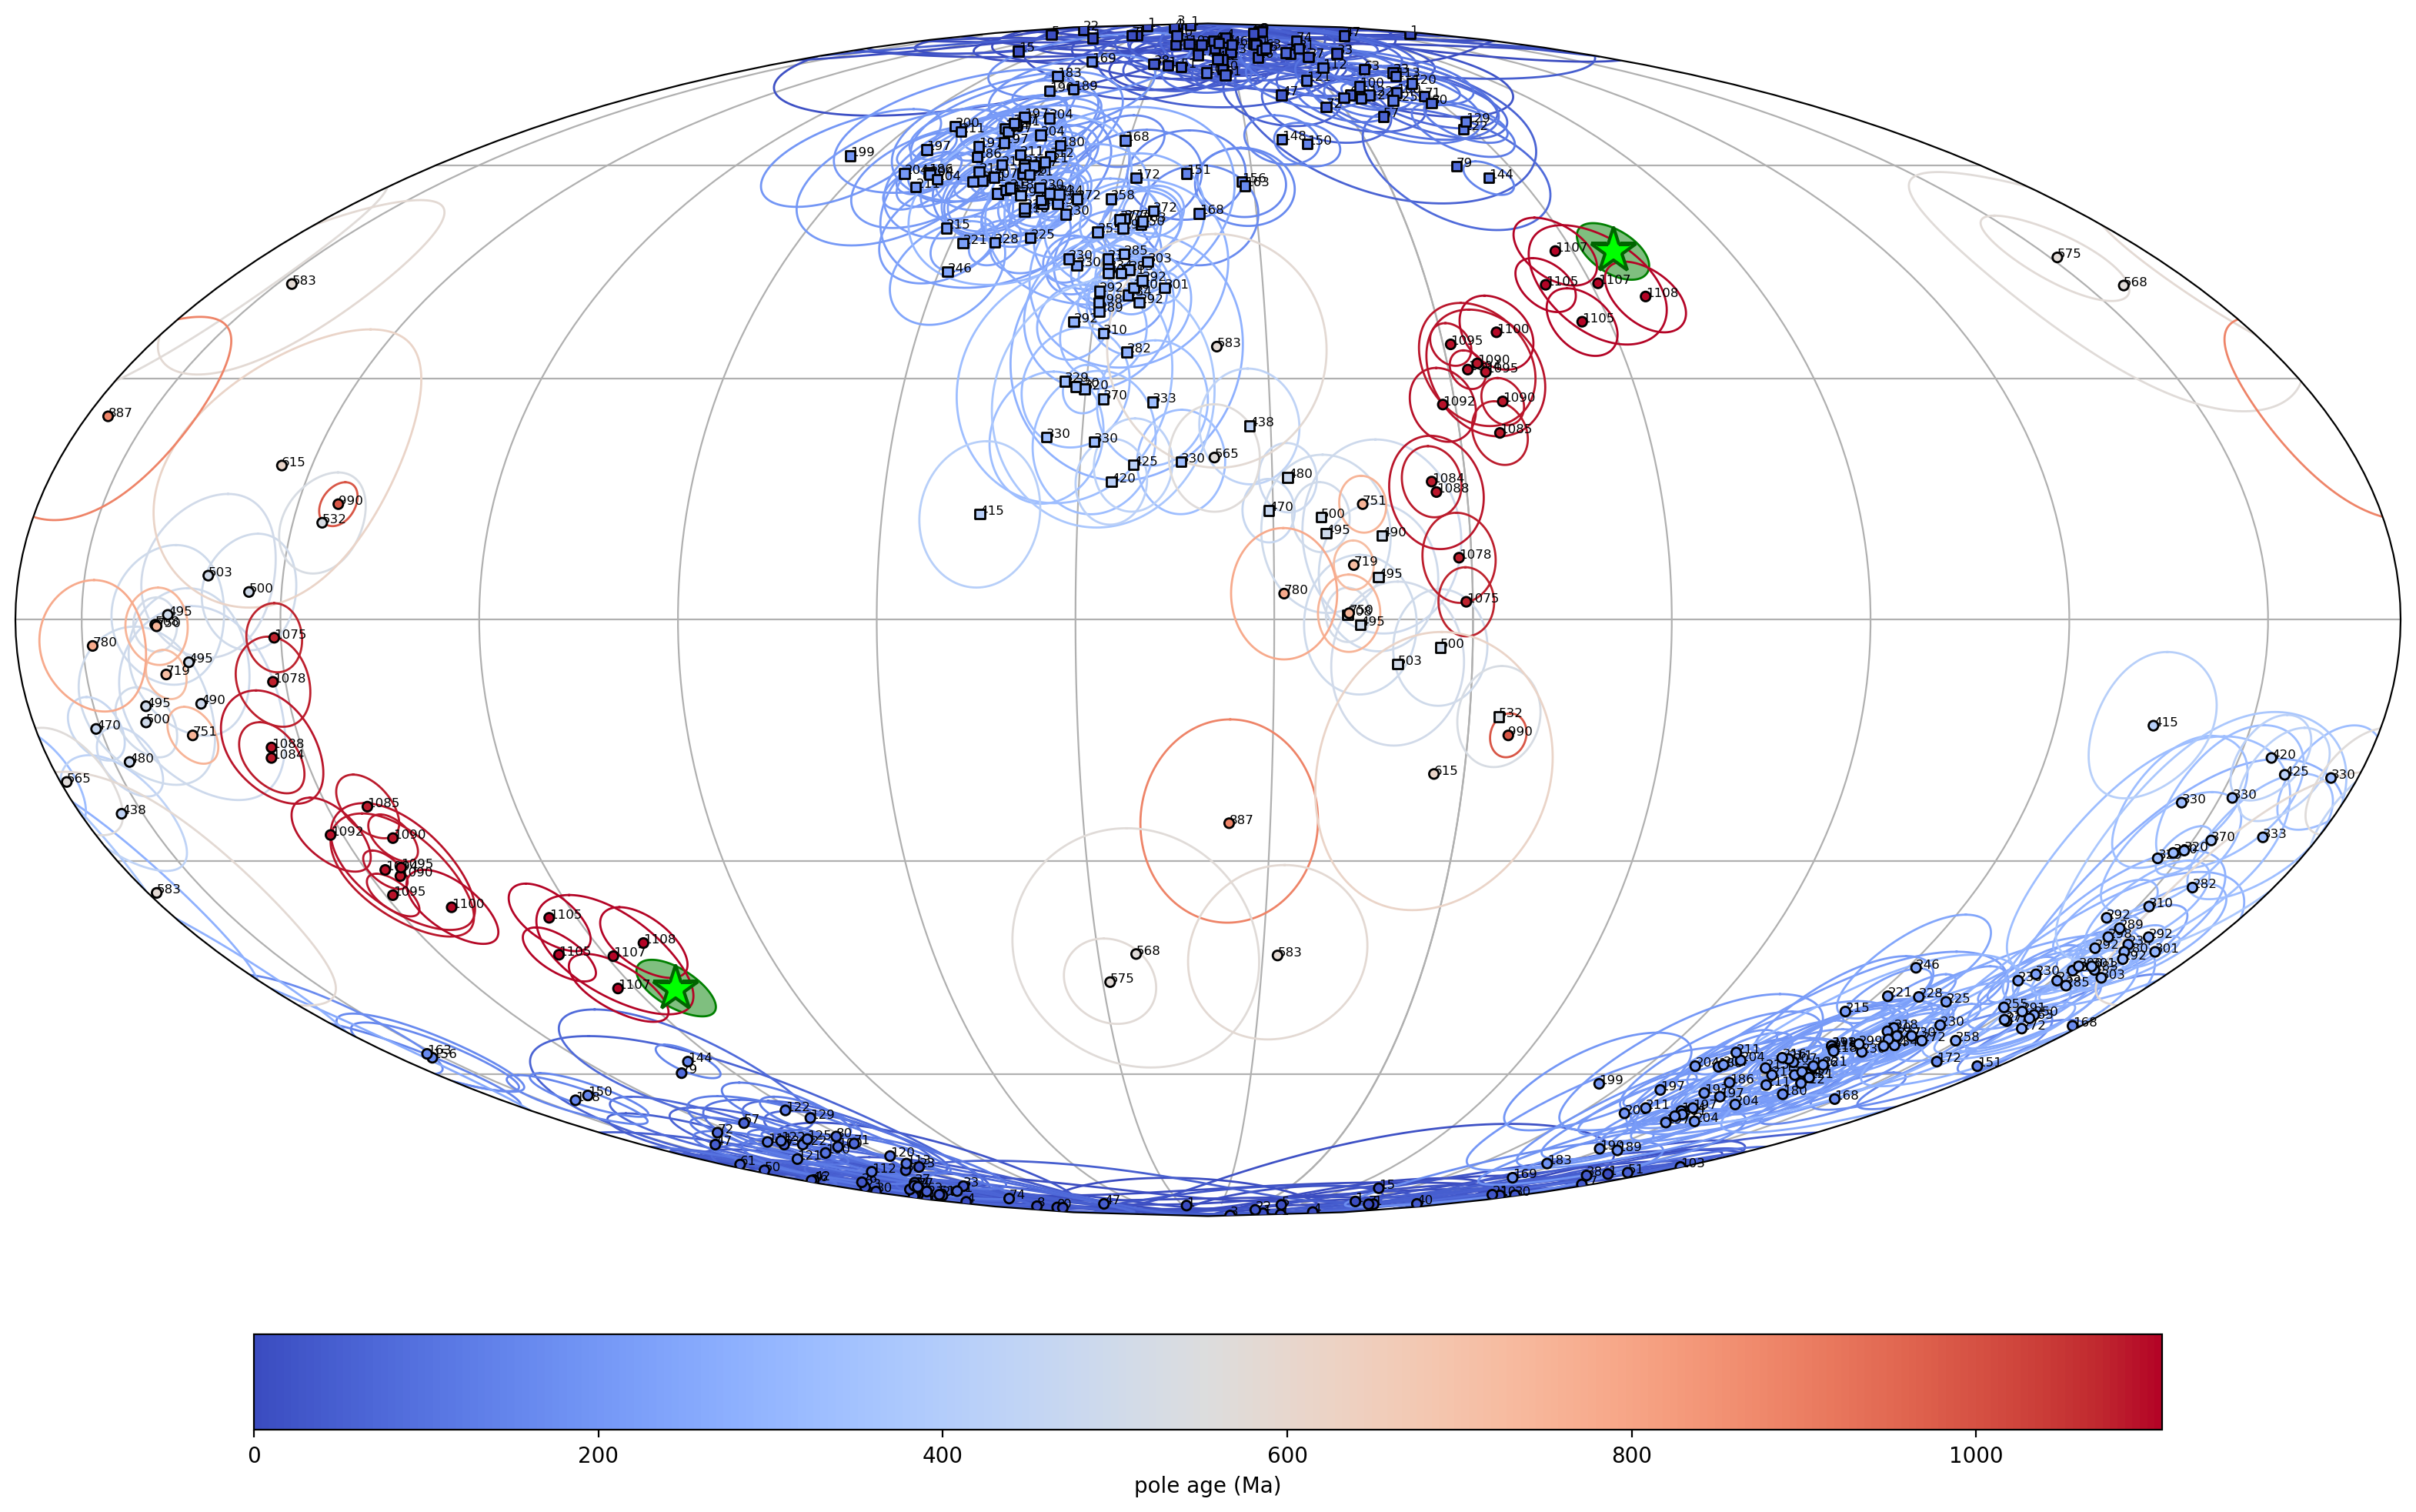

In [5]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('MEAN Nipigon sills and lavas', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1108)
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format. Because this is a published grand mean rather than a recomputed site-level pole, the site/sample counts (B = 86, N = 1000) and direction precision (KD = 1000, ED95 = 0.1) are the placeholder values carried in the source compilation for a mean of unit means; the meaningful quantities are the pole position (47.2 degrees N / 217.8 degrees E, A95 4.0 degrees) and the reassigned 1108 +/- 2 Ma age.

In [6]:
# published grand mean (no per-site VGPs digitized here): represent it with a
# single placeholder "sites" row carrying the compilation's count and tilt state
nip_sites = pd.DataFrame([{'dir_tilt_correction': int(float(nip['TILT'])),
                           'dir_n_samples': int(float(nip['N']))}])

nipigon_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Nipigon sills and lavas',
    sites=nip_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(nip['SLONG']),
    study_lat=float(nip['SLAT']),
    component_comment=('Single reverse-polarity remanence; Lulea Working Group eight-unit grand mean '
                       '(Inspiration sills, Pillar Lake lava, Seagull intrusion, Nipigon sills, '
                       'Logan sills x3, Thunder Bay reverse dykes), as compiled by Evans et al. (2021)'),
    tests='c+ (positive inverse baked-contact constraint)',
    gpmdb_number='',
    magic_id='',
    percent_reversed=int(float(nip['%REV'])),
    demag_code=int(float(nip['DEMAGCODE'])),
    R1=1, R2=0, R3=1, R4='c', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1108, lomagage=1106, himagage=1110,
    REF_method=('Nipigon (Logan) sills cluster at ca. 1105-1109 Ma: Nipigon sills 1108.2 +/- 0.9 Ma '
                '(zircon, recalculated from Davis and Sutcliffe, 1985); new U-Pb dates of '
                '1106.3 +/- 2.0 Ma (Logan Sill, Mt. McKay) and 1105.5 +/- 3.0 Ma (Inspiration sill) '
                'from Bleeker et al. (2020). Assigned 1108 +/- 2 Ma.'),
    POLE_AUTHORS=('Lulea Working Group mean (sources: Borradaile et al., 2006; Middleton et al., 2004; '
                  'Pesonen, 1979; Robertson and Fahrig, 1971; Palmer, 1970)'),
    YEAR=2009,
    JOURNAL='',
    VOLUME='',
    VPAGES='',
    TITLE='MEAN Nipigon sills and lavas (Lulea Working Group grand mean)',
    COMMENT=('Pole taken from the Evans et al. (2021) Laurentia compilation (Lulea Working Group '
             'eight-unit grand mean, 2009); single reverse polarity (R6=0). R2=0 and the KD=1000 / '
             'N=1000 / ED95=0.1 fields are the sentinel values of the source mean-of-means. Age '
             'reassigned to 1108 +/- 2 Ma from Nipigon/Logan sill U-Pb geochronology (Davis and '
             'Sutcliffe, 1985 recalculation; Bleeker et al., 2020).')
)
pt.save_nordic_summary(nipigon_summary, '1108_Nipigon')
nipigon_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Nipigon sills and lavas,,Single reverse-polarity remanence; Lulea Worki...,c+ (positive inverse baked-contact constraint),0,49.1,270.9,86,1000,...,1110,Nipigon (Logan) sills cluster at ca. 1105-1109...,Nipigon sills and lavas,Lulea Working Group mean (sources: Borradaile ...,2009,,,,MEAN Nipigon sills and lavas (Lulea Working Gr...,Pole taken from the Evans et al. (2021) Lauren...
